# AML Transaction Monitoring

Rank synthetic banking transactions for analyst review under a fixed **1% review budget**. Compare logistic regression and random forest on chronological validation data, then evaluate the selected model on a later held-out test period.

Dataset: IBM **HI-Small**. See [README.md](README.md) for the source, environment setup, results, and limitations. Run this notebook from the repository root, top to bottom.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('HI-Small_Trans.csv')

df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


# Data Cleaning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 699.6 MB


In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 5078336 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 741.9 MB


In [6]:
print(df.isna().sum())

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64


# Split

In [7]:
# Convert the timestamp column into actual dates
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="raise")

# Arrange transactions from oldest to newest
df = df.sort_values("Timestamp").reset_index(drop=True)

# Find timestamps around the 70% and 85% positions
train_cutoff = df["Timestamp"].iloc[int(len(df) * 0.70)]
test_cutoff = df["Timestamp"].iloc[int(len(df) * 0.85)]

# Oldest ~70%: training
train_df = df[df["Timestamp"] < train_cutoff].copy()

# Next ~15%: validation
val_df = df[
    (df["Timestamp"] >= train_cutoff)
    & (df["Timestamp"] < test_cutoff)
].copy()

# Newest ~15%: testing
test_df = df[df["Timestamp"] >= test_cutoff].copy()

for name, data in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Testing", test_df),
]:
    print(f"\n{name}: {len(data):,} transactions")
    print("From:", data["Timestamp"].min())
    print("To:  ", data["Timestamp"].max())

    # Change this if your label column has a different name
    print(data["Is Laundering"].value_counts())


Training: 3,554,647 transactions
From: 2022-09-01 00:00:00
To:   2022-09-07 14:54:00
Is Laundering
0    3551791
1       2856
Name: count, dtype: int64

Validation: 761,590 transactions
From: 2022-09-07 14:55:00
To:   2022-09-09 03:15:00
Is Laundering
0    760830
1       760
Name: count, dtype: int64

Testing: 762,099 transactions
From: 2022-09-09 03:16:00
To:   2022-09-18 16:18:00
Is Laundering
0    760538
1      1561
Name: count, dtype: int64


# Features

In [8]:
import numpy as np
# When did the transaction happen?
df["hour"] = df["Timestamp"].dt.hour
df["day_of_week"] = df["Timestamp"].dt.dayofweek

# Monday = 0, Sunday = 6
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Did the transfer go between different banks?
df["different_bank"] = (
    df["From Bank"] != df["To Bank"]
).astype(int)

# Compress large amounts so their scale is less extreme
# Assumes amounts are nonnegative
df["log_amount"] = np.log1p(df["Amount Paid"])

# Use bank + account to identify a sender.
# Include currency so we don't average different currencies together.
sender_keys = ["From Bank", "Account", "Payment Currency"]

# Combine transactions that share a sender, currency, and timestamp
history = (
    df.groupby(sender_keys + ["Timestamp"], as_index=False)
      .agg(
          transactions_at_time=("Amount Paid", "size"),
          amount_at_time=("Amount Paid", "sum")
      )
      .sort_values("Timestamp")
)

# Count transactions strictly BEFORE the current timestamp
history["previous_transaction_count"] = (
    history.groupby(sender_keys)["transactions_at_time"].cumsum()
    - history["transactions_at_time"]
)

# Sum amounts strictly BEFORE the current timestamp
history["previous_total_amount"] = (
    history.groupby(sender_keys)["amount_at_time"].cumsum()
    - history["amount_at_time"]
)

# Average prior amount; stays missing when there is no history
history["previous_average_amount"] = (
    history["previous_total_amount"]
    / history["previous_transaction_count"].replace(0, np.nan)
)

# Attach the historical features to each original transaction
df = df.merge(
    history[
        sender_keys
        + [
            "Timestamp",
            "previous_transaction_count",
            "previous_average_amount"
        ]
    ],
    on=sender_keys + ["Timestamp"],
    how="left",
    validate="many_to_one"
)

# Compare this transaction with the sender's previous average
df["amount_vs_previous_average"] = (
    df["Amount Paid"]
    / df["previous_average_amount"].replace(0, np.nan)
)

feature_columns = [
    "hour",
    "day_of_week",
    "is_weekend",
    "different_bank",
    "log_amount",
    "previous_transaction_count",
    "previous_average_amount",
    "amount_vs_previous_average"
]

df[["Timestamp", "Amount Paid"] + feature_columns].head(10)

train_df = df[df["Timestamp"] < train_cutoff].copy()

val_df = df[
    (df["Timestamp"] >= train_cutoff)
    & (df["Timestamp"] < test_cutoff)
].copy()

test_df = df[df["Timestamp"] >= test_cutoff].copy()

# Train (Logistic Regression)

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

numeric_features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "different_bank",
    "log_amount",
    "previous_transaction_count",
    "previous_average_amount",
    "amount_vs_previous_average"
]

categorical_features = [
    "Payment Currency",
    "Payment Format"
]

features = numeric_features + categorical_features

# Training inputs and correct answers
X_train = train_df[features].copy()
y_train = train_df["Is Laundering"].copy()

# Validation inputs and correct answers
X_val = val_df[features].copy()
y_val = val_df["Is Laundering"].copy()

# Treat any infinite numeric values as missing
X_train[numeric_features] = X_train[numeric_features].replace(
    [np.inf, -np.inf], np.nan
)

X_val[numeric_features] = X_val[numeric_features].replace(
    [np.inf, -np.inf], np.nan
)

# Numeric columns: fill missing values, then scale
numeric_processor = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

# Text columns: fill missing values, then encode as numeric columns
categorical_processor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the appropriate preparation to each group of columns
preprocessor = ColumnTransformer([
    ("numeric", numeric_processor, numeric_features),
    ("categorical", categorical_processor, categorical_features)
])


model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Training complete!")

# Predicted class: 0 or 1
val_predictions = model.predict(X_val)

# Score for class 1: laundering
val_scores = model.predict_proba(X_val)[:, 1]

print("First 10 predictions:", val_predictions[:10])
print("First 10 scores:", val_scores[:10])

Training complete!


First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 scores: [0.05680314 0.16643349 0.10592669 0.10734679 0.00042849 0.16941039
 0.07781564 0.12628531 0.05057994 0.11806327]


# Model (Random Forest)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.pipeline import Pipeline

# Keep the trained logistic regression
logistic_model = model

random_forest_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=50,          # Fewer trees
        max_depth=10,             # Smaller trees
        min_samples_leaf=20,
        max_samples=100_000,      # At most 100k sampled rows per tree
        class_weight="balanced_subsample",
        n_jobs=2,                # Leave some CPU capacity available
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random forest training complete!")

Random forest training complete!


# Logistic Regression vs. Random Forest

The 0.50 threshold table below is a diagnostic comparison. **Model selection and the main results use recall at a fixed 1% review budget**, chosen before evaluating the test set. Average precision measures ranking quality across thresholds.


In [11]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

results = []
validation_scores = {}

for name, trained_model in models.items():

    # Get laundering scores
    scores = trained_model.predict_proba(X_val)[:, 1]
    validation_scores[name] = scores

    # Start with a cutoff of 0.5
    predictions = (scores >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val, predictions, labels=[0, 1]
    ).ravel()

    results.append({
        "Model": name,
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_val, predictions, zero_division=0
        ),
        "Average Precision": average_precision_score(y_val, scores),
        "Laundering Caught": tp,
        "Laundering Missed": fn,
        "False Alerts": fp,
        "Total Alerts": tp + fp
    })

comparison = pd.DataFrame(results).set_index("Model")

display(comparison.round(4))

,Precision,Recall,F1,Average Precision,Laundering Caught,Laundering Missed,False Alerts,Total Alerts
Model,,,,,,,,
Logistic Regression,0.0056,0.9289,0.011,0.0068,706,54,126389,127095
Random Forest,0.0359,0.6382,0.068,0.0925,485,275,13028,13513


In [12]:
review_fraction = 0.01

def evaluate_at_budget(labels, scores, fraction):
    """Rank a period's transactions; equal scores retain input row order."""
    actual = np.asarray(labels)
    scores = np.asarray(scores)
    assert len(actual) == len(scores) and len(actual) > 0
    assert np.isin(actual, [0, 1]).all() and np.isfinite(scores).all()
    assert 0 < fraction <= 1

    number_to_review = max(1, int(len(actual) * fraction))
    top_indices = np.argsort(-scores, kind="stable")[:number_to_review]
    caught = int(actual[top_indices].sum())
    total_positive = int(actual.sum())
    prevalence = total_positive / len(actual)
    precision = caught / number_to_review

    return {
        "Transactions": len(actual),
        "Labelled Laundering": total_positive,
        "Prevalence": prevalence,
        "Transactions Reviewed": number_to_review,
        "Laundering Caught": caught,
        "Laundering Missed": total_positive - caught,
        "False Alerts": number_to_review - caught,
        "Precision at Budget": precision,
        "Recall at Budget": caught / total_positive if total_positive else np.nan,
        "Lift over Random": precision / prevalence if prevalence else np.nan,
        "Average Precision": (
            average_precision_score(actual, scores) if total_positive else np.nan
        ),
    }

budget_comparison = pd.DataFrame.from_dict({
    name: evaluate_at_budget(y_val, scores, review_fraction)
    for name, scores in validation_scores.items()
}, orient="index").rename_axis("Model")

display(budget_comparison.round(4))


,Transactions,Labelled Laundering,Prevalence,Transactions Reviewed,Laundering Caught,Laundering Missed,False Alerts,Precision at Budget,Recall at Budget,Lift over Random,Average Precision
Model,,,,,,,,,,,
Logistic Regression,761590,760,0.001,7615,16,744,7599,0.0021,0.0211,2.1055,0.0068
Random Forest,761590,760,0.001,7615,384,376,7231,0.0504,0.5053,50.5323,0.0925


Matplotlib is building the font cache; this may take a moment.


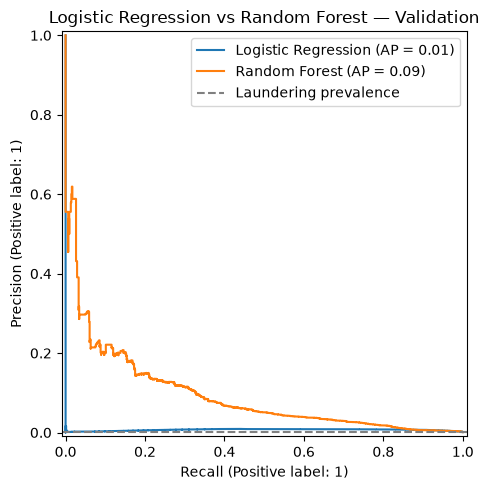

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 5))

for name, scores in validation_scores.items():
    PrecisionRecallDisplay.from_predictions(
        y_val,
        scores,
        name=name,
        ax=ax
    )

# Reference: the proportion of transactions labelled laundering
ax.axhline(
    y=y_val.mean(),
    color="gray",
    linestyle="--",
    label="Laundering prevalence"
)

ax.set_title("Logistic Regression vs Random Forest — Validation")
ax.legend()
plt.tight_layout()
plt.show()

# Final held-out evaluation

Freeze the model using **validation recall at the existing 1% budget**. If recalls tie, keep the first model in the comparison. Keep the fitted training-only pipeline; do not refit or tune on the test period.

Historical features use transactions strictly earlier than the scored timestamp, including earlier transactions within validation/test periods, without using their labels. This assumes past transaction records are available at scoring time.

In [14]:
chosen_model = budget_comparison["Recall at Budget"].idxmax()
selected_model = models[chosen_model]
print(f"Selected on validation only: {chosen_model}; review budget: {review_fraction:.0%}")

Selected on validation only: Random Forest; review budget: 1%


In [15]:
# Apply the same feature preparation as training and validation.
X_test = test_df[features].copy()
y_test = test_df["Is Laundering"].copy()
X_test[numeric_features] = X_test[numeric_features].replace(
    [np.inf, -np.inf], np.nan
)

assert train_df["Timestamp"].max() < val_df["Timestamp"].min()
assert val_df["Timestamp"].max() < test_df["Timestamp"].min()
assert X_test.index.equals(y_test.index)

test_scores = selected_model.predict_proba(X_test)[:, 1]
test_result = evaluate_at_budget(y_test, test_scores, review_fraction)
display(pd.DataFrame([test_result], index=[chosen_model]).round(4))

,Transactions,Labelled Laundering,Prevalence,Transactions Reviewed,Laundering Caught,Laundering Missed,False Alerts,Precision at Budget,Recall at Budget,Lift over Random,Average Precision
Random Forest,762099,1561,0.002,7620,812,749,6808,0.1066,0.5202,52.0247,0.2314


# Inspection

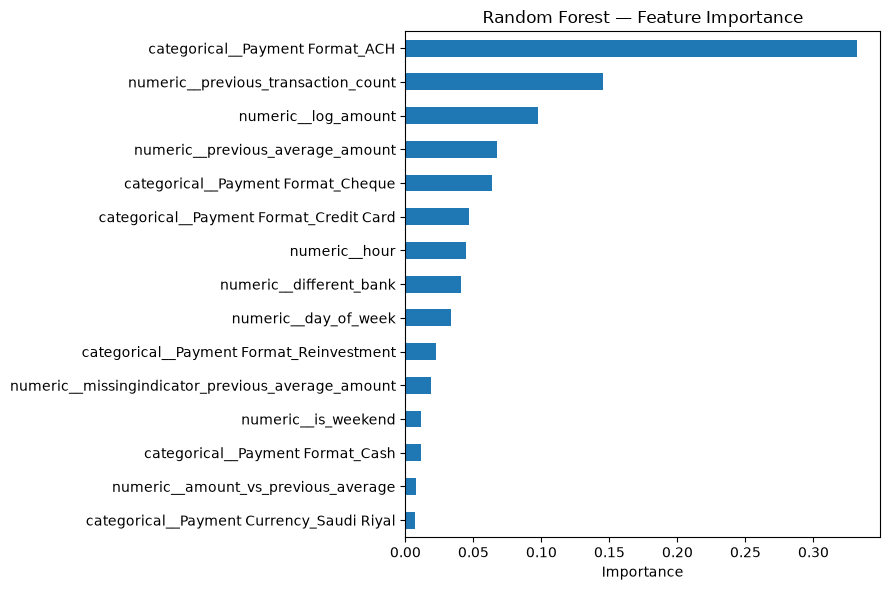

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.Series(
    random_forest_model
    .named_steps["classifier"]
    .feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance.head(15).sort_values().plot.barh(figsize=(9, 6))

plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [17]:
# Ensure transaction details and model inputs have the same row order.
assert val_df.index.equals(X_val.index)

alerts = val_df.copy()
# Preserve the notebook row order as a reproducible score tie-breaker.
alerts["transaction_id"] = alerts.index
alerts["risk_score"] = validation_scores[chosen_model]

# Descriptive context for an analyst, not model explanations.
def describe_transaction(row):
    observations = []
    ratio = row["amount_vs_previous_average"]
    if pd.notna(ratio) and ratio >= 5:
        observations.append(
            f"Amount is {ratio:.1f}× the sender's prior average"
        )
    if row["previous_transaction_count"] == 0:
        observations.append("No prior sender history in this currency")
    if row["different_bank"] == 1:
        observations.append("Transfer between different banks")
    return "; ".join(observations) or "Review transaction history"

alerts["review_context"] = alerts.apply(describe_transaction, axis=1)
alerts = alerts.sort_values(
    ["risk_score", "transaction_id"], ascending=[False, True]
)

display(alerts[[
    "transaction_id", "Timestamp", "Account", "Account.1", "Amount Paid",
    "Payment Currency", "risk_score", "review_context", "Is Laundering"
]].head(10))


,transaction_id,Timestamp,Account,Account.1,Amount Paid,Payment Currency,risk_score,review_context,Is Laundering
3559688,3559688,2022-09-07 15:10:00,81359A920,81359A740,16740.17,US Dollar,0.980318,No prior sender history in this currency; Tran...,0
3562387,3562387,2022-09-07 15:18:00,805AD2D20,8027C1CE0,12020.12,US Dollar,0.980318,No prior sender history in this currency; Tran...,1
3568209,3568209,2022-09-07 15:36:00,80B32CD50,80B32C900,2593444.90,US Dollar,0.980318,No prior sender history in this currency; Tran...,0
3581094,3581094,2022-09-07 16:15:00,80390F790,808B1C350,15924.14,US Dollar,0.980318,No prior sender history in this currency; Tran...,1
3589211,3589211,2022-09-07 16:39:00,8036095E0,803724320,13795.25,US Dollar,0.980318,No prior sender history in this currency; Tran...,1
3593563,3593563,2022-09-07 16:53:00,806CBBE20,80171C720,14546.79,US Dollar,0.980318,No prior sender history in this currency; Tran...,1
3596592,3596592,2022-09-07 17:02:00,812046160,812046250,46670.97,US Dollar,0.980318,No prior sender history in this currency; Tran...,0
3608328,3608328,2022-09-07 17:38:00,80D9C1280,80D9C1460,25434.15,US Dollar,0.980318,No prior sender history in this currency; Tran...,0
3620123,3620123,2022-09-07 18:14:00,80615D270,8051AA8E0,15342.07,US Dollar,0.980318,No prior sender history in this currency; Tran...,1
3587701,3587701,2022-09-07 16:35:00,809283410,809283D70,7520.71,US Dollar,0.980232,No prior sender history in this currency; Tran...,0


# Results at the fixed 1% review budget

Validation selects the model; the held-out test period estimates performance on later transactions. The budget is `max(1, floor(0.01 × period size))`, applied to each complete period. This is a retrospective ranking simulation, not a daily or real-time alert limit. No score threshold or model parameter is tuned on test labels.


In [18]:
from IPython.display import display, HTML

validation_result = evaluate_at_budget(
    y_val, validation_scores[chosen_model], review_fraction
)
final_results = pd.DataFrame([
    {"Split": "Validation", "Model": chosen_model, **validation_result},
    {"Split": "Test", "Model": chosen_model, **test_result},
]).set_index("Split")

display(HTML(final_results.to_html(formatters={
    "Prevalence": "{:.3%}".format,
    "Precision at Budget": "{:.2%}".format,
    "Recall at Budget": "{:.2%}".format,
    "Lift over Random": "{:.1f}×".format,
    "Average Precision": "{:.4f}".format,
})))

print(
    f"Held-out test: {chosen_model} catches "
    f"{test_result['Laundering Caught']:,} of "
    f"{test_result['Labelled Laundering']:,} labelled laundering transactions "
    f"({test_result['Recall at Budget']:.2%} recall) while reviewing "
    f"{test_result['Transactions Reviewed']:,} transactions "
    f"at the {review_fraction:.0%} budget. "
    f"Precision is {test_result['Precision at Budget']:.2%}, "
    f"with {test_result['False Alerts']:,} false alerts."
)
print(
    "Scores are rankings, not calibrated probabilities. Synthetic-data results "
    "do not establish real-world detection performance."
)


,Model,Transactions,Labelled Laundering,Prevalence,Transactions Reviewed,Laundering Caught,Laundering Missed,False Alerts,Precision at Budget,Recall at Budget,Lift over Random,Average Precision
Split,,,,,,,,,,,,
Validation,Random Forest,761590,760,0.100%,7615,384,376,7231,5.04%,50.53%,50.5×,0.0925
Test,Random Forest,762099,1561,0.205%,7620,812,749,6808,10.66%,52.02%,52.0×,0.2314


Held-out test: Random Forest catches 812 of 1,561 labelled laundering transactions (52.02% recall) while reviewing 7,620 transactions at the 1% budget. Precision is 10.66%, with 6,808 false alerts.
Scores are rankings, not calibrated probabilities. Synthetic-data results do not establish real-world detection performance.


# Dashboard exports

Export ranked validation and test queues plus a small benchmark summary. The dashboard reads these artifacts; it does not retrain a model. The CSV files are generated locally and excluded from Git.


In [19]:
from pathlib import Path
import json
import platform
from importlib.metadata import version

output_dir = Path("app")
output_dir.mkdir(exist_ok=True)

assert test_df.index.equals(X_test.index)
test_alerts = test_df.copy()
test_alerts["transaction_id"] = test_alerts.index
test_alerts["risk_score"] = test_scores
test_alerts["review_context"] = test_alerts.apply(describe_transaction, axis=1)
test_alerts = test_alerts.sort_values(
    ["risk_score", "transaction_id"], ascending=[False, True]
)

export_columns = [
    "transaction_id", "Timestamp", "From Bank", "Account", "To Bank",
    "Account.1", "Amount Paid", "Payment Currency", "Payment Format",
    "risk_score", "review_context", "Is Laundering",
]
for split, queue in [("validation", alerts), ("test", test_alerts)]:
    queue[export_columns].to_csv(output_dir / f"{split}_alerts.csv", index=False)
    print(f"Saved {split} queue: {len(queue):,} transactions")

summary_rows = final_results.reset_index().to_dict(orient="records")
for row, data in zip(summary_rows, [val_df, test_df]):
    row["Start"] = str(data["Timestamp"].min())
    row["End"] = str(data["Timestamp"].max())

summary = {
    "model": chosen_model,
    "review_fraction": review_fraction,
    "selection_metric": "Validation recall at the fixed 1% review budget",
    "tie_breaker": "Ascending transaction_id (notebook row order)",
    "train_cutoff": str(train_cutoff),
    "test_cutoff": str(test_cutoff),
    "versions": {
        "python": platform.python_version(),
        **{package: version(package) for package in [
            "pandas", "numpy", "scikit-learn", "matplotlib"
        ]},
    },
    "validation_models": budget_comparison.reset_index().to_dict(orient="records"),
    "splits": summary_rows,
}
(output_dir / "evaluation_summary.json").write_text(
    json.dumps(summary, indent=2, allow_nan=False) + "\n"
)
print("Saved benchmark summary: app/evaluation_summary.json")


Saved validation queue: 761,590 transactions


Saved test queue: 762,099 transactions
Saved benchmark summary: app/evaluation_summary.json


Start the dashboard from the repository root after running this notebook:

```bash
python -m streamlit run app/dashboard.py
```

Dependencies are listed in `requirements.txt`. The dashboard implementation lives in `app/dashboard.py`; rerunning this notebook only regenerates its data.